In [ ]:
#1 FIND S'ALGORITHM
import pandas as pd
import numpy as np

# Training dataset
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)
print("Training Data:")
print(df)

# FIND-S algorithm
attributes = list(df.columns[:-1])
hypothesis = ['0'] * len(attributes)

for _, row in df.iterrows():
    if row['EnjoySport'] == 'Yes':
        for i, attr in enumerate(attributes):
            if hypothesis[i] == '0':
                hypothesis[i] = row[attr]
            elif hypothesis[i] != row[attr]:
                hypothesis[i] = '?'

print("\nMost Specific Hypothesis:")
print(hypothesis)

Training Data:
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Most Specific Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


In [ ]:
# 2.Candidate Elimination Algorithm
import pandas as pd

# Dataset
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)
print(df)

attributes = list(df.columns[:-1])
S = ['0'] * len(attributes)
G = [['?'] * len(attributes)]

def consistent(h, x):
    return all(h[i] == '?' or h[i] == x[i] for i in range(len(h)))

for _, row in df.iterrows():
    x = row[attributes].tolist()
    label = row['EnjoySport']

    if label == 'Yes':
        # Remove inconsistent general hypotheses
        G = [g for g in G if consistent(g, x)]

        for i in range(len(S)):
            if S[i] == '0':
                S[i] = x[i]
            elif S[i] != x[i]:
                S[i] = '?'

    else:
        # Remove general hypotheses that cover negative example
        G = [g for g in G if not consistent(g, x)]

print("\nSpecific Boundary S:")
print(S)

print("\nGeneral Boundary G:")
for g in G:
    print(g)

     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Specific Boundary S:
['Sunny', 'Warm', '?', 'Strong', '?', '?']

General Boundary G:


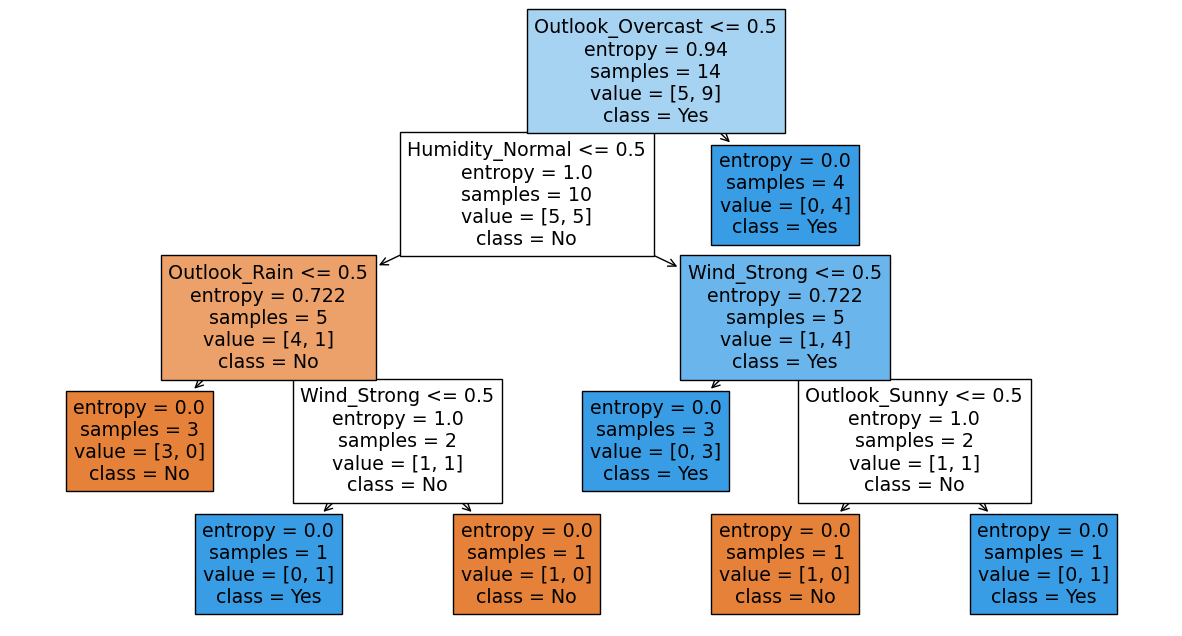

Prediction: No


In [ ]:
# 3.ID3 Decision Tree
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

data = {
    'Outlook': ['Sunny','Sunny','Overcast','Rain','Rain','Rain',
                'Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild',
                    'Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity': ['High','High','High','High','Normal','Normal','Normal',
                 'High','Normal','Normal','Normal','High','Normal','High'],
    'Wind': ['Weak','Strong','Weak','Weak','Weak','Strong','Strong',
             'Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play': ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes',
             'Yes','Yes','Yes','No']
}

df = pd.DataFrame(data)

X = pd.get_dummies(df.drop('Play', axis=1))
y = df['Play']

model = DecisionTreeClassifier(criterion='entropy', random_state=42)
model.fit(X, y)

plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns,
          class_names=model.classes_, filled=True)
plt.show()

# New sample
new_sample = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}])

new_sample = pd.get_dummies(new_sample)
new_sample = new_sample.reindex(columns=X.columns, fill_value=0)

print("Prediction:", model.predict(new_sample)[0])

In [ ]:
# 4.ANN using Backpropagation
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN with backpropagation
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted:", y_pred)
print("Actual:   ", y_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Predicted: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual:    [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 1.0


In [ ]:
#5. KNN Classification
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ANN with backpropagation
model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted:", y_pred)
print("Actual:   ", y_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Predicted: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual:    [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 1.0


In [ ]:
# 6.Naive Bayes Classification
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 1.0


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


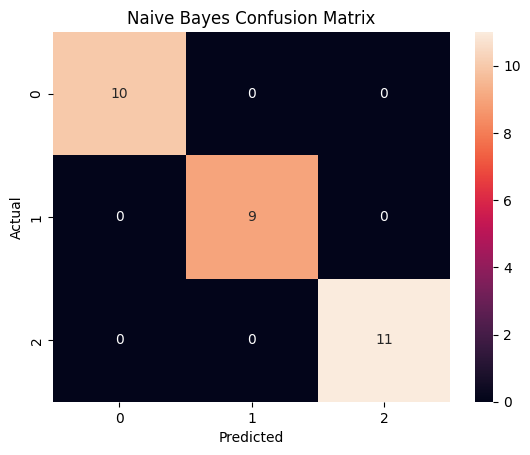

In [1]:
# 7.Logistic Regression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [ ]:
# 8.Linear Regression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:", y_pred)
print("Accuracy:", accuracy_score(y_test, y_pred))

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 1.0


Slope: 2.0000000000000004
Intercept: 0.9999999999999982
MSE: 3.944304526105059e-31
R2 Score: 1.0


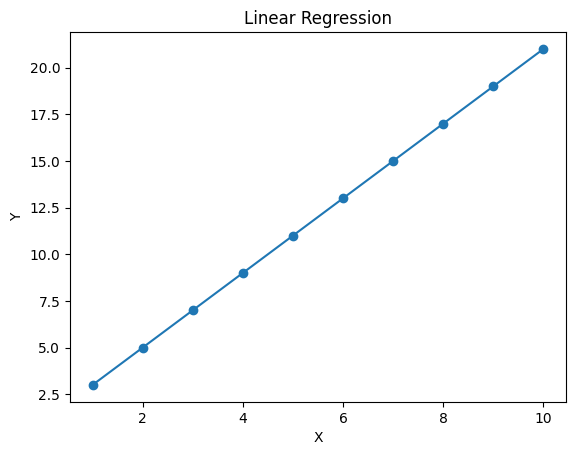

In [ ]:
# 9.Linear vs Polynomial Regression
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([3,5,7,9,11,13,15,17,19,21])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression")
plt.show()

Linear Regression MSE: 52.79999999999997
Polynomial Regression MSE: 2.3922206950827182e-29


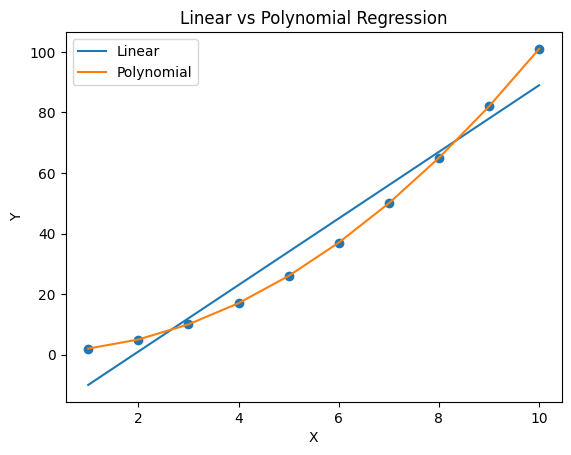

In [ ]:
# 10.Expectation Maximization using Gaussian Mixture Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

X = np.array([[1],[2],[3],[4],[5],[6],[7],[8],[9],[10]])
y = np.array([2,5,10,17,26,37,50,65,82,101])

# Linear Regression
linear = LinearRegression()
linear.fit(X, y)
linear_pred = linear.predict(X)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

polynomial = LinearRegression()
polynomial.fit(X_poly, y)
poly_pred = polynomial.predict(X_poly)

print("Linear Regression MSE:",
      mean_squared_error(y, linear_pred))

print("Polynomial Regression MSE:",
      mean_squared_error(y, poly_pred))

plt.scatter(X, y)
plt.plot(X, linear_pred, label="Linear")
plt.plot(X, poly_pred, label="Polynomial")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Linear vs Polynomial Regression")
plt.show()

Cluster Means:
[[1.94221787 2.01701116]
 [7.06412436 7.02174382]]

Cluster Covariances:
[[[ 0.1814859   0.00684244]
  [ 0.00684244  0.24693631]]

 [[ 0.26748247 -0.02010586]
  [-0.02010586  0.2162743 ]]]


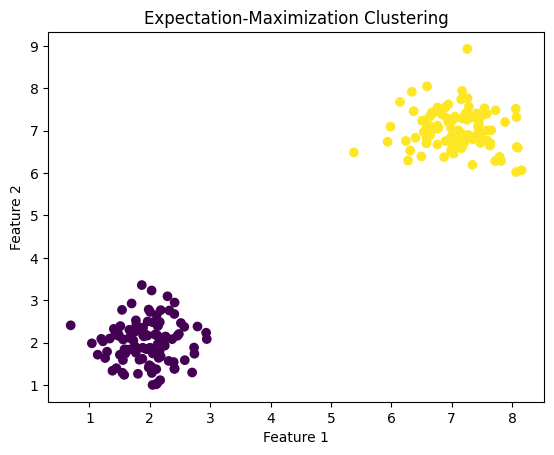

In [ ]:
# 11. Credit Score Classification
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

np.random.seed(42)

# Generate sample data
X1 = np.random.normal(2, 0.5, (100, 2))
X2 = np.random.normal(7, 0.5, (100, 2))

X = np.vstack((X1, X2))

# EM algorithm using Gaussian Mixture Model
model = GaussianMixture(n_components=2, random_state=42)
model.fit(X)

labels = model.predict(X)

print("Cluster Means:")
print(model.means_)

print("\nCluster Covariances:")
print(model.covariances_)

plt.scatter(X[:,0], X[:,1], c=labels)
plt.title("Expectation-Maximization Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [ ]:
# 12.Iris Classification using KNN
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

# Generate sample credit data
n = 500

income = np.random.randint(20000, 100000, n)
debt = np.random.randint(1000, 50000, n)
age = np.random.randint(20, 65, n)
credit_history = np.random.randint(1, 20, n)

X = np.column_stack((income, debt, age, credit_history))

score = income - debt + credit_history * 3000
y = np.where(score > 50000, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.85      0.83      0.84        35
           1       0.91      0.92      0.92        65

    accuracy                           0.89       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.89      0.89      0.89       100



In [ ]:
# 13.Car Price Prediction
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, prediction))

# New flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

result = model.predict(new_flower)

print("Predicted Flower:",
      iris.target_names[result[0]])

Accuracy: 1.0
Predicted Flower: setosa


In [ ]:
# 14.House Price Prediction
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)

# Sample car dataset
n = 300

age = np.random.randint(1, 15, n)
km = np.random.randint(5000, 150000, n)
engine = np.random.randint(800, 3000, n)
horsepower = np.random.randint(60, 250, n)

price = (
    2500000
    - age * 100000
    - km * 5
    + engine * 500
    + horsepower * 3000
    + np.random.normal(0, 50000, n)
)

X = np.column_stack((age, km, engine, horsepower))
y = price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

# New car
new_car = [[3, 30000, 1500, 120]]

print("Predicted Car Price:",
      model.predict(new_car)[0])

MAE: 138445.2542879597
R2 Score: 0.9065313472412244
Predicted Car Price: 3127995.284474817


In [ ]:
# 15.Iris Classification using Naive Bayes
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

np.random.seed(42)

n = 500

area = np.random.randint(500, 5000, n)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 5, n)
age = np.random.randint(0, 30, n)

price = (
    area * 5000
    + bedrooms * 300000
    + bathrooms * 200000
    - age * 50000
    + np.random.normal(0, 100000, n)
)

X = np.column_stack((area, bedrooms, bathrooms, age))
y = price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

new_house = [[2000, 3, 2, 5]]

print("Predicted House Price:",
      model.predict(new_house)[0])

MAE: 350607.7401628089
R2 Score: 0.9950530140749884
Predicted House Price: 11052844.784832152


In [ ]:
# 16.Compare Classification Algorithms
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

new_flower = [[5.1, 3.5, 1.4, 0.2]]

result = model.predict(new_flower)

print("\nNew Flower:",
      iris.target_names[result[0]])

Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

New Flower: setosa


Algorithm Performance:

Logistic Regression : 1.0
Decision Tree : 1.0
KNN : 1.0
Naive Bayes : 1.0
SVM : 1.0


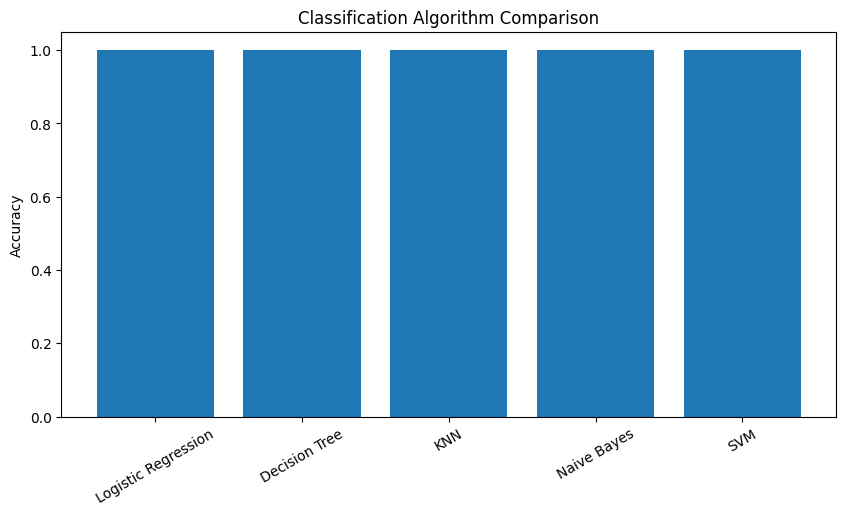

In [ ]:
# 17.Mobile Price Prediction
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import matplotlib.pyplot as plt

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, pred)

print("Algorithm Performance:\n")

for name, accuracy in results.items():
    print(name, ":", accuracy)

plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Classification Algorithm Comparison")
plt.show()

In [ ]:
# 18.Perceptron Iris Classification
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

n = 1000

ram = np.random.randint(1, 13, n)
battery = np.random.randint(2000, 7000, n)
storage = np.random.choice([32, 64, 128, 256, 512], n)
camera = np.random.randint(5, 108, n)

# Price category
score = ram * 10 + battery / 500 + storage / 32 + camera / 10

y = np.where(score < 60, 0,
             np.where(score < 100, 1, 2))

X = np.column_stack((ram, battery, storage, camera))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

new_mobile = [[8, 5000, 128, 50]]

result = model.predict(new_mobile)[0]

categories = ["Low Price", "Medium Price", "High Price"]

print("Predicted Mobile Price Category:",
      categories[result])

Accuracy: 0.98
Predicted Mobile Price Category: Medium Price


In [ ]:
# 19.Bank Loan Prediction using Naive Bayes
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

# Use only two classes for binary perceptron classification
X = X[y != 2]
y = y[y != 2]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Perceptron(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Predictions:", pred)
print("Actual:", y_test)
print("Accuracy:", accuracy_score(y_test, pred))

new_flower = scaler.transform(
    [[5.1, 3.5, 1.4, 0.2]]
)

print("Predicted Class:",
      iris.target_names[model.predict(new_flower)[0]])

Predictions: [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
Actual: [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
Accuracy: 1.0
Predicted Class: setosa
